In [1]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
# from general_utils.utils import decode_matlab_strings, load_img_natraster, TimeSeries, dRSA, get_relevant_output_layers
from general_utils.II import InformationImbalance

In [5]:
neural = np.loadtxt("/Users/tizianocausin/Library/CloudStorage/GoogleDrive-tiziano.causin@unitn.it/My Drive/for_alessandro/neural_activity_100ms.csv", delimiter=",")
model = np.loadtxt("/Users/tizianocausin/Library/CloudStorage/GoogleDrive-tiziano.causin@unitn.it/My Drive/for_alessandro/features_block_0.csv", delimiter=",")


In [26]:
def compute_hist_II(ii_obj, II_type: str):
    if II_type == 'A2B':
        conditioning_var = 'signal'
        conditioned_var = 'model'
    elif II_type == 'B2A':
        conditioning_var = 'model'
        conditioned_var = 'signal'
    # end if II_type == 'A2B':
    conditioning_mins = getattr(ii_obj, f"{conditioning_var}_kmins_idx")
    to_be_conditioned_ranks = getattr(ii_obj, f"{conditioned_var}_distance_ranks")
    conditioned_ranks = 2*np.take_along_axis(to_be_conditioned_ranks, conditioning_mins, axis=0)/ii_obj.N
    return conditioned_ranks
# EOF

In [ ]:
ii_obj_euc = InformationImbalance("euclidean", "euclidean", k=1)
ii_obj_euc.compute_both_RDMs(neural, model)
ii_obj_euc.compute_both_distance_ranks()


(array([[4378.,  348., 1715., ...,  446., 1918., 1669.],
        [ 150., 4378., 1732., ...,  454.,  654.,  943.],
        [3802., 3991., 4378., ..., 4109., 3621.,  665.],
        ...,
        [ 447.,  826., 2317., ..., 4378., 2550., 2909.],
        [1242.,  539., 1115., ..., 1772., 4378.,  356.],
        [3064., 2566.,  372., ..., 3959., 1545., 4378.]]),
 array([[3584, 2853,  201, ..., 3802,  645,  213]]),
 array([[4.378e+03, 2.704e+03, 1.471e+03, ..., 3.480e+03, 3.689e+03,
         3.566e+03],
        [2.509e+03, 4.378e+03, 2.698e+03, ..., 1.710e+03, 2.151e+03,
         2.086e+03],
        [8.000e+00, 6.650e+02, 4.378e+03, ..., 1.758e+03, 1.787e+03,
         1.701e+03],
        ...,
        [3.291e+03, 1.390e+03, 3.066e+03, ..., 4.378e+03, 1.100e+01,
         1.100e+01],
        [3.393e+03, 2.273e+03, 3.092e+03, ..., 1.400e+01, 4.378e+03,
         1.000e+00],
        [3.298e+03, 1.992e+03, 2.998e+03, ..., 1.300e+01, 2.000e+00,
         4.378e+03]]),
 array([[  74, 4158, 4182, ..., 278

In [20]:
ii_obj_cos = InformationImbalance("cosine", "cosine", k=1)
ii_obj_cos.compute_both_RDMs(neural, model)
ii_obj_cos.compute_both_distance_ranks()

(array([[4378.,  710., 1902., ...,  847., 2253., 1993.],
        [ 560., 4378., 1757., ..., 1171., 1618., 1198.],
        [1024.,  938., 4378., ..., 1909.,  312.,  361.],
        ...,
        [ 966., 1366., 2557., ..., 4378., 2647., 2962.],
        [2039., 1351.,  907., ..., 2380., 4378.,  448.],
        [1541.,  711.,  593., ..., 2655.,  216., 4378.]]),
 array([[ 449, 1659, 2778, ..., 3469, 2539, 4182]]),
 array([[4.378e+03, 2.402e+03, 1.657e+03, ..., 3.653e+03, 3.631e+03,
         3.631e+03],
        [2.555e+03, 4.378e+03, 2.722e+03, ..., 2.004e+03, 2.859e+03,
         2.637e+03],
        [1.200e+01, 3.570e+02, 4.378e+03, ..., 1.731e+03, 1.806e+03,
         1.678e+03],
        ...,
        [3.322e+03, 2.076e+03, 3.094e+03, ..., 4.378e+03, 1.100e+01,
         1.100e+01],
        [3.382e+03, 3.127e+03, 3.105e+03, ..., 1.400e+01, 4.378e+03,
         1.000e+00],
        [3.310e+03, 2.814e+03, 3.019e+03, ..., 1.300e+01, 2.000e+00,
         4.378e+03]]),
 array([[  74, 4158, 3991, ..., 278

In [27]:
pd_euc = np.squeeze(compute_hist_II(ii_obj_euc, 'B2A'))
pd_cos = np.squeeze(compute_hist_II(ii_obj_cos, 'B2A'))

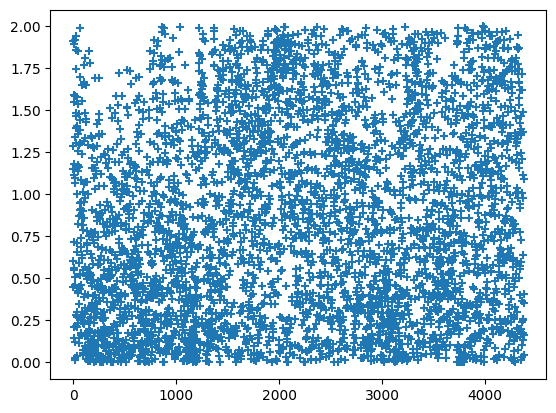

In [28]:
plt.scatter(np.arange(pd_euc.shape[0]), pd_cos, marker='+')

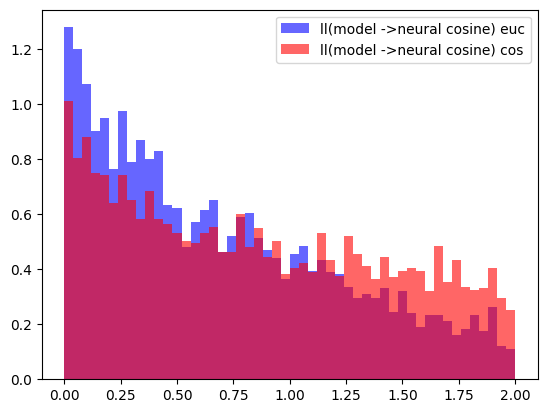

In [33]:
bins=50; range_vals=(0,2)
plt.hist(pd_euc, bins=bins, range=range_vals, density=True, 
         alpha=0.6, color='blue', label='ll(model ->neural cosine) euc')
plt.hist(pd_cos, bins=bins, range=range_vals, density=True, 
         alpha=0.6, color='red', label='ll(model ->neural cosine) cos')
plt.legend()

In [61]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=neural.shape[1], metric="cosine").fit(neural.T)
distances, indices = nbrs.kneighbors(neural.T)



In [60]:
from scipy.spatial.distance import squareform
np.allclose(indices, np.argsort(squareform(ii_obj_euc.get_RDM("signal")), axis=1))

True

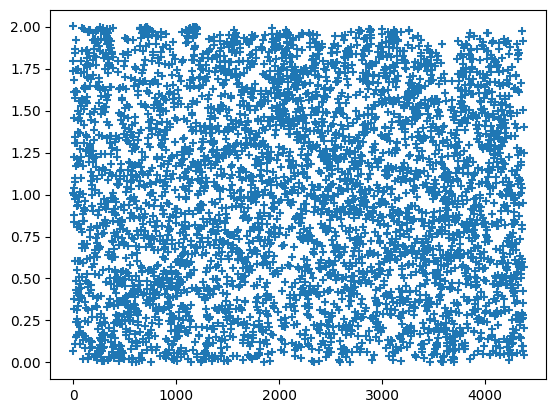

In [57]:
plt.scatter(np.arange(4377), ii_obj_euc.get_distance_ranks('signal')[:, 0]*2/4377, marker='+')

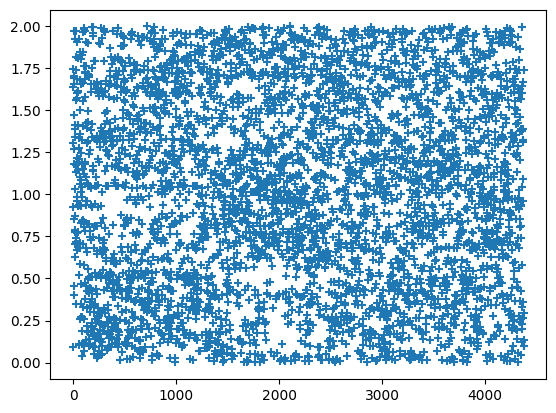

In [55]:
plt.scatter(np.arange(4377), indices[:, 1]*2/4377, marker='+')
